## Plot Cole Anticevic Network atlas

In [2]:
import numpy as np
from matplotlib.colors import ListedColormap

In [20]:
import matplotlib.patches as mpatches
import hcp_utils as hcp
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
# Add grey color at the beginning
grey = np.array([[0.5, 0.5, 0.5, 1.0]])  # RGBA format: grey with full opacity
cmap_ca = ListedColormap( np.vstack([grey, rgb]))

#legend_patches = [mpatches.Patch(color=cmap_ca(i-1), label=row['Network Name'])  for i, row in CAatlas_names.iterrows()]
from numrisk.fmri_analysis.gradients.utils import get_glasser_CAatlas_mapping, get_glasser_parcels
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

In [14]:
CAatlas_names

,Network Name
Label Number,
1,Visual1
2,Visual2
3,Somatomotor
4,Cingulo-Opercular
5,Dorsal-attention
6,Language
7,Frontoparietal
8,Auditory
9,Default


In [12]:
from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , 
                                     labeling_glasser, mask=mask_glasser, fill=0) #, fill=np.nan) #grad_sub[n_grad-1]


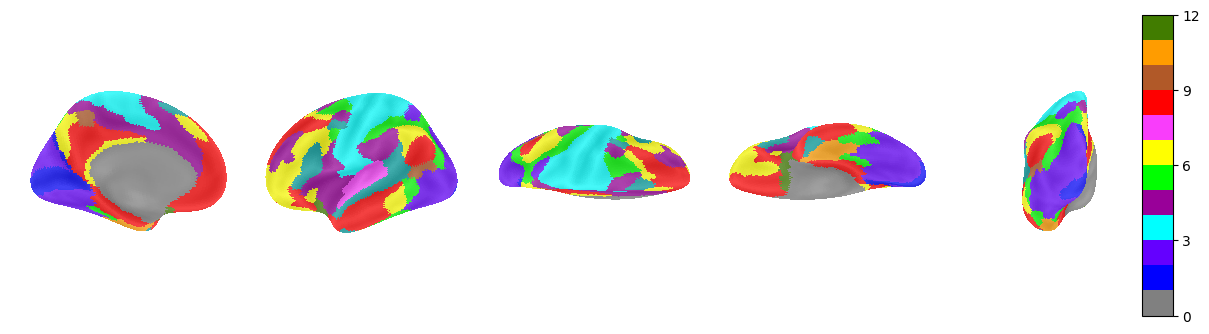

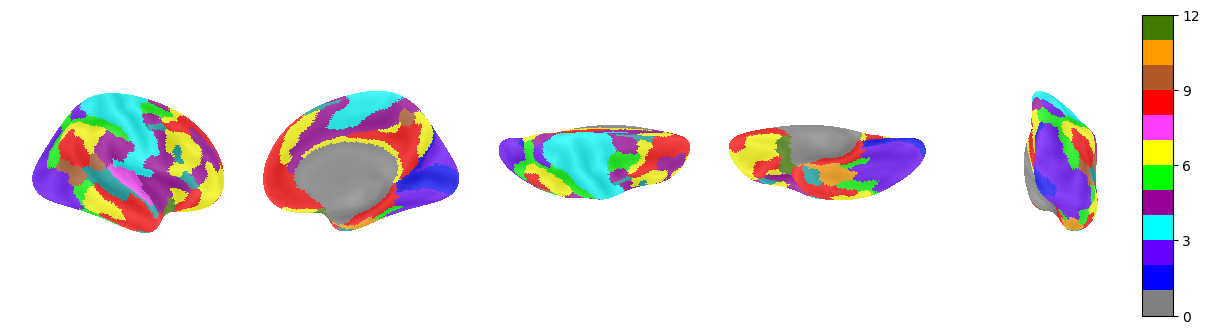

In [19]:
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt 
import matplotlib.pyplot as plt

fsaverage = fetch_surf_fsaverage('fsaverage5') 
views = ['medial','lateral','dorsal','ventral','posterior']
cmap = cmap_ca #'viridis'

surf_map = caNets_fsav5_mapping

for i, hemi in enumerate(['L','R']):
    map = np.split(surf_map,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, avg_method = 'median',# infl_right # pial_right
                view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)


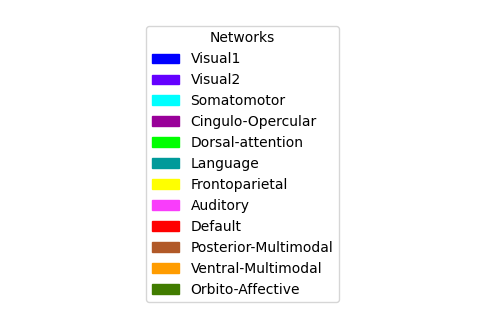

In [21]:
cmap_ca = ListedColormap(rgb)
legend_patches = [mpatches.Patch(color=cmap_ca(i-1), label=row['Network Name'])  for i, row in CAatlas_names.iterrows()]

# Plot the custom legend
plt.figure(figsize=(6, 4))
plt.legend(handles=legend_patches, title="Networks", loc="center")
plt.axis('off')  # Hide axis for a standalone legend
plt.show()